# YOLO Vehicle & Pedestrian Detection
![image.png](./image.png)
### Computer Vision Project

This notebook demonstrates how to use a pre-trained YOLO model to detect specific classes of objects in a video stream.
We will be detecting:
- Cars (Class 2)
- Motorcycles (Class 3)
- Buses (Class 5)
- Trucks (Class 7)

In [ ]:
# Combined Object Counting and Sidewalk Violation Detection
import cv2
import torch
from ultralytics import YOLO, solutions
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from collections import defaultdict, deque

# --- 1. SETUP & CONFIGURATION ---

# Check GPU
print(f"CUDA status: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Current VRAM Allocated: {torch.cuda.memory_allocated(0) / 1024**2:.2f} MB")

# Define file paths and settings
video_source = "CCTV_Sleman.mp4"
model_path = "yolo11m.pt"
tracker_cfg = "bytetrack_tuned.yaml"
target_classes = [2, 3, 5, 7]  # Cars(2), Motorcycles(3), Buses(5), Trucks(7)

# Minimum pixel movement per frame to be considered "moving" (avoids flagging stopped vehicles)
MOVEMENT_THRESHOLD = 5
MAX_MISSED_FRAMES = 30

# --- 2. REGION DEFINITIONS ---

# Initialize video capture to get dimensions
cap = cv2.VideoCapture(video_source)
assert cap.isOpened(), "Error reading video file"
w, h, fps = (int(cap.get(x)) for x in (cv2.CAP_PROP_FRAME_WIDTH, cv2.CAP_PROP_FRAME_HEIGHT, cv2.CAP_PROP_FPS))

# Line Counting Region (Horizontal line)
line_points = [(0, int(h / 1.55)), (w, int(h / 1.55))]

# Sidewalk Zones (Polygons) - pre-converted to numpy for efficiency
sidewalk_zones_np = [
    np.array([(48, 1041), (755, 251), (788, 253), (160, 1041)], np.int32),   # LEFT SIDEWALK
    np.array([(1266, 277), (1919, 961), (1919, 839), (1318, 281)], np.int32), # RIGHT SIDEWALK
]

# Divider-based guard so road traffic near the midline is ignored
road_divider_x = int(w / 1.88)
divider_buffer_px = 80  # widen or shrink if mid-road false positives persist

# --- 3. INITIALIZATION ---

# Output video writer
output_filename = "11m_monitoring_output.mp4"
video_writer = cv2.VideoWriter(output_filename, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

# Initialize ObjectCounter for the Line (handles tracking and counting)
counter = solutions.ObjectCounter(
    model=model_path,
    region=line_points,
    classes=target_classes,
    tracker=tracker_cfg,
    show=False,
    line_width=2,
 )

def init_kalman(x, y):
    kf = cv2.KalmanFilter(4, 2)
    kf.transitionMatrix = np.array([[1, 0, 1, 0],
                                    [0, 1, 0, 1],
                                    [0, 0, 1, 0],
                                    [0, 0, 0, 1]], dtype=np.float32)
    kf.measurementMatrix = np.array([[1, 0, 0, 0],
                                     [0, 1, 0, 0]], dtype=np.float32)
    kf.processNoiseCov = np.eye(4, dtype=np.float32) * 1e-2
    kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 1e-1
    kf.errorCovPost = np.eye(4, dtype=np.float32)
    kf.statePost = np.array([[x], [y], [0], [0]], dtype=np.float32)
    return kf

# Initialize variables for Sidewalk violations
left_sidewalk_violations = 0   # Left zone: wrong direction = moving DOWN (y increasing)
right_sidewalk_violations = 0  # Right zone: wrong direction = moving UP (y decreasing)
violation_ids = set()

# Track previous centroid positions to determine movement direction
# { track_id: (x, y) }
prev_positions = {}

# Tracklet features (history + aggregates)
TRACKLET_HISTORY = 30  # number of points kept per active track
tracklet_history = defaultdict(lambda: deque(maxlen=TRACKLET_HISTORY))
tracklet_distance = defaultdict(float)   # cumulative travel distance in pixels
tracklet_conf_sum = defaultdict(float)   # sum of confidences for avg confidence
tracklet_frames_seen = defaultdict(int)
tracklet_first_last = {}                 # {track_id: [first_frame, last_frame]}
tracklet_class_votes = defaultdict(lambda: defaultdict(int))
tracklet_speed_values = defaultdict(list)       # per-step speed samples (px/s)
tracklet_step_distance_values = defaultdict(list)  # per-step distance samples (px)
tracklet_kf = {}  # Kalman filter per track id
tracklet_missed_frames = defaultdict(int)

frame_count = 0
fps_smooth = None
print(f"Starting combined monitoring on {video_source}...")
print(f"Left zone violation = moving DOWN | Right zone violation = moving UP")
print(f"Tracker config: {tracker_cfg} | missed frame grace: {MAX_MISSED_FRAMES}")

# --- 4. MAIN PROCESSING LOOP ---
while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break
    
    frame_start_time = time.time()
    frame_count += 1
    
    # Process the frame with the Line Counter
    result = counter(frame)
    im0 = result.plot_im 

    # Draw the sidewalk zones once per frame (outside the per-object loop)
    overlay = im0.copy()
    cv2.fillPoly(overlay, sidewalk_zones_np, (0, 0, 255))
    cv2.addWeighted(overlay, 0.2, im0, 0.8, 0, im0)
    cv2.line(im0, (road_divider_x, 0), (road_divider_x, h), (0, 255, 255), 1)  # show divider reference
    frame_track_speeds = []
    
    # --- DIRECTIONAL SIDEWALK ZONE CHECK ---
    if counter.track_ids:
        confs = counter.confs if getattr(counter, "confs", None) is not None else [None] * len(counter.track_ids)
        for track_id, box, cls, conf in zip(counter.track_ids, counter.boxes, counter.clss, confs):
            
            # Explicitly cast to float to ensure cv2 compatibility
            x_center = float((box[0] + box[2]) / 2)
            y_center = float((box[1] + box[3]) / 2)
            x1 = int(float(box[0]))
            y1 = int(float(box[1]))

            if track_id not in tracklet_kf:
                tracklet_kf[track_id] = init_kalman(x_center, y_center)
            kf = tracklet_kf[track_id]
            kf.predict()
            kf_state = kf.correct(np.array([[x_center], [y_center]], dtype=np.float32))
            kf_x = float(kf_state[0, 0])
            kf_y = float(kf_state[1, 0])
            current_point = (kf_x, kf_y)

            # --- Tracklet feature updates ---
            tracklet_frames_seen[track_id] += 1
            tracklet_class_votes[track_id][int(cls)] += 1
            if conf is not None:
                tracklet_conf_sum[track_id] += float(conf)

            if track_id not in tracklet_first_last:
                tracklet_first_last[track_id] = [frame_count, frame_count]
            else:
                tracklet_first_last[track_id][1] = frame_count

            history = tracklet_history[track_id]
            step_distance = 0.0
            had_prev = bool(history)
            if had_prev:
                prev_hx, prev_hy = history[-1]
                step_distance = float(np.hypot(kf_x - prev_hx, kf_y - prev_hy))
                tracklet_distance[track_id] += step_distance
            history.append((kf_x, kf_y))

            # Approximate speed in px/s from inter-frame displacement
            instant_speed = step_distance * fps
            frame_track_speeds.append(instant_speed)
            if had_prev:
                tracklet_step_distance_values[track_id].append(step_distance)
                tracklet_speed_values[track_id].append(instant_speed)
            
            # Check if point is inside each zone and on the correct half of the road
            is_in_left  = (
                cv2.pointPolygonTest(sidewalk_zones_np[0], current_point, False) >= 0
                and kf_x <= road_divider_x - divider_buffer_px
            )
            is_in_right = (
                cv2.pointPolygonTest(sidewalk_zones_np[1], current_point, False) >= 0
                and kf_x >= road_divider_x + divider_buffer_px
            )

            # Determine movement direction using previous position
            is_moving_down = False  # y increasing -> moving down in image
            is_moving_up   = False  # y decreasing -> moving up in image

            if track_id in prev_positions:
                prev_x, prev_y = prev_positions[track_id]
                dy = kf_y - prev_y  # positive = moving down, negative = moving up

                if dy > MOVEMENT_THRESHOLD:
                    is_moving_down = True
                elif dy < -MOVEMENT_THRESHOLD:
                    is_moving_up = True
                # else: |dy| <= threshold -> considered stopped, no violation
            
            # Update position history
            prev_positions[track_id] = (kf_x, kf_y)

            # Flag violation only if in zone AND moving the wrong direction
            is_left_violation  = is_in_left  and is_moving_down
            is_right_violation = is_in_right and is_moving_up

            if track_id not in violation_ids:
                if is_left_violation:
                    left_sidewalk_violations += 1
                    violation_ids.add(track_id)
                elif is_right_violation:
                    right_sidewalk_violations += 1
                    violation_ids.add(track_id)

            # Highlight active violators (currently in zone + wrong direction)
            if is_left_violation or is_right_violation:
                cv2.circle(im0, (int(kf_x), int(kf_y)), 12, (0, 0, 255), -1)
                cv2.putText(im0, "VIOLATION", (x1, max(15, y1 - 10)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
            # Dim highlight for previously recorded violators still in frame
            elif track_id in violation_ids and (is_in_left or is_in_right):
                cv2.circle(im0, (int(kf_x), int(kf_y)), 8, (0, 165, 255), 2)

            # Always show confidence near each tracked box
            dominant_cls = max(tracklet_class_votes[track_id], key=tracklet_class_votes[track_id].get)
            avg_conf = (tracklet_conf_sum[track_id] / tracklet_frames_seen[track_id]) if tracklet_frames_seen[track_id] else 0.0

            if len(history) >= 2:
                pts = np.array([(int(px), int(py)) for px, py in history], dtype=np.int32)
                cv2.polylines(im0, [pts], False, (255, 200, 0), 2)

            cv2.putText(
                im0,
                f"ID {int(track_id)} C{int(dominant_cls)} AvgC:{avg_conf:.2f}",
                (x1, max(20, y1 - 30)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                (255, 255, 0),
                2,
            )
            cv2.putText(
                im0,
                f"v:{instant_speed:.1f}px/s x:{int(kf_x)} y:{int(kf_y)}",
                (x1, max(40, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 220, 255),
                2,
            )

    # Keep track state alive for short misses to reduce blinking
    active_ids = set(counter.track_ids) if counter.track_ids else set()
    for tid in active_ids:
        tracklet_missed_frames[tid] = 0

    for tid in list(tracklet_kf.keys()):
        if tid in active_ids:
            continue

        tracklet_missed_frames[tid] += 1
        if tracklet_missed_frames[tid] <= MAX_MISSED_FRAMES:
            continue

        del tracklet_kf[tid]
        if tid in prev_positions:
            del prev_positions[tid]
        if tid in tracklet_history:
            del tracklet_history[tid]
        if tid in tracklet_missed_frames:
            del tracklet_missed_frames[tid]

    # Compute real-time FPS (smoothed for readability)
    frame_time = max(time.time() - frame_start_time, 1e-6)
    current_fps = 1.0 / frame_time
    fps_smooth = current_fps if fps_smooth is None else (0.9 * fps_smooth + 0.1 * current_fps)

    # Add custom dashboard text
    total_vehicle_count = counter.in_count + counter.out_count
    active_tracks = len(counter.track_ids) if counter.track_ids else 0
    avg_track_speed = (sum(frame_track_speeds) / len(frame_track_speeds)) if active_tracks else 0.0
    cv2.putText(im0, f"Processing FPS: {fps_smooth:.2f}", 
                (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
    cv2.putText(im0, f"Video FPS (source): {fps:.2f}", 
                (20, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (180, 180, 180), 2)
    cv2.putText(im0, f"Total Vehicles: {total_vehicle_count}", 
                (20, 100), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
    cv2.putText(im0, f"Active Tracks: {active_tracks} | Avg speed: {avg_track_speed:.1f}px/s", 
                (20, 180), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 220, 120), 2)
    cv2.putText(im0, f"Left Violations (down): {left_sidewalk_violations}", 
                (20, 140), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
    cv2.putText(im0, f"Right Violations (up): {right_sidewalk_violations}", 
                (w - 520, 140), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
    
    # Write to video
    video_writer.write(im0)

    # Progress update
    if frame_count % 30 == 0:
        print(f"Processed {frame_count} frames... | FPS: {fps_smooth:.2f}", end='\r')

    # # Safety break for testing (remove to run full video)
    # if frame_count > 30: 
    #     print("\nReached frame limit.")
    #     break

# --- 5. CLEANUP ---
cap.release()
video_writer.release()
cv2.destroyAllWindows()

print(f"\nProcessing finished. Saved to '{output_filename}'")
print(f"Total Vehicles Counted: {counter.in_count + counter.out_count}")
print(f"Left Sidewalk Violations (moving down): {left_sidewalk_violations}")
print(f"Right Sidewalk Violations (moving up):  {right_sidewalk_violations}")
print(f"Total Unique Violators: {len(violation_ids)}")

# --- 6. FEATURE EXTRACTION (ID + speed/distance avg, min, max) ---
feature_rows = []
for tid in sorted(tracklet_frames_seen.keys()):
    speed_vals = tracklet_speed_values.get(tid, [])
    dist_vals = tracklet_step_distance_values.get(tid, [])

    speed_avg = float(np.mean(speed_vals)) if speed_vals else 0.0
    speed_min = float(np.min(speed_vals)) if speed_vals else 0.0
    speed_max = float(np.max(speed_vals)) if speed_vals else 0.0
    dist_avg = float(np.mean(dist_vals)) if dist_vals else 0.0
    dist_min = float(np.min(dist_vals)) if dist_vals else 0.0
    dist_max = float(np.max(dist_vals)) if dist_vals else 0.0

    feature_rows.append({
        "id": int(tid),
        "speed_avg_px_s": speed_avg,
        "speed_min_px_s": speed_min,
        "speed_max_px_s": speed_max,
        "distance_avg_px": dist_avg,
        "distance_min_px": dist_min,
        "distance_max_px": dist_max,
    })

tracklet_feature_df = pd.DataFrame(feature_rows)
if not tracklet_feature_df.empty:
    tracklet_feature_df = tracklet_feature_df.sort_values("id").reset_index(drop=True)
    print("Tracklet feature extraction complete:")
    display(tracklet_feature_df)
    tracklet_feature_df.to_csv("tracklet_features.csv", index=False)
    print("Saved features to tracklet_features.csv")
else:
    print("No tracklet features were extracted.")

if tracklet_distance:
    print("Top tracklets by distance (pixels):")
    top_tracklets = sorted(tracklet_distance.items(), key=lambda x: x[1], reverse=True)[:5]
    for tid, dist in top_tracklets:
        first_f, last_f = tracklet_first_last.get(tid, [frame_count, frame_count])
        duration_s = (last_f - first_f + 1) / max(fps, 1)
        avg_conf = (tracklet_conf_sum[tid] / tracklet_frames_seen[tid]) if tracklet_frames_seen[tid] else 0.0
        cls_votes = tracklet_class_votes[tid]
        dominant_cls = max(cls_votes, key=cls_votes.get) if cls_votes else -1
        print(f"  ID {int(tid)} | dist={dist:.1f}px | dur={duration_s:.2f}s | avg_conf={avg_conf:.2f} | class={int(dominant_cls)}")

CUDA status: True
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU
Current VRAM Allocated: 0.00 MB
Ultralytics Solutions:  {'source': None, 'model': 'yolo11m.pt', 'classes': [2, 3, 5, 7], 'show_conf': True, 'show_labels': True, 'region': [(0, 696), (1920, 696)], 'colormap': 21, 'show_in': True, 'show_out': True, 'up_angle': 145.0, 'down_angle': 90, 'kpts': [6, 8, 10], 'analytics_type': 'line', 'figsize': (12.8, 7.2), 'blur_ratio': 0.5, 'vision_point': (20, 20), 'crop_dir': 'cropped-detections', 'json_file': None, 'line_width': 2, 'records': 5, 'fps': 30.0, 'max_hist': 5, 'meter_per_pixel': 0.05, 'max_speed': 120, 'show': False, 'iou': 0.7, 'conf': 0.25, 'device': None, 'max_det': 300, 'half': False, 'tracker': 'bytetrack_tuned.yaml', 'verbose': True, 'data': 'images'}
Starting combined monitoring on CCTV_Sleman.mp4...
Left zone violation = moving DOWN | Right zone violation = moving UP
Tracker config: bytetrack_tuned.yaml | missed frame grace: 30


[Full YOLO model testing video](https://youtu.be/gKysf4sNiO8)
![yolo sample](./sample.png)
![violator sample](./Violator.png)

## VAE Anomaly Detection Pipeline (Left/Right Specialized)
This pipeline trains two Temporal VAE models split by road divider:
- Left-side model focuses only on left roadway region.
- Right-side model focuses only on right roadway region.

Execution order:
1. Run Cell 5 (build divider ROIs + load/train left/right VAEs + loaders).
2. Run Cell 6 (calibrate left/right thresholds + detect + combined timeline output).

Notes:
- Training source folders are separated: `vae_split_samples/left` and `vae_split_samples/right`.
- Divider source uses `road_divider_x` from YOLO cell when available.
- If `road_divider_x` is missing, divider is estimated from frame width (`w / 1.88`).
- Separate weights are used for each side (`temporal_vae_left_weights.pt`, `temporal_vae_right_weights.pt`).

In [ ]:
from pathlib import Path
import cv2
import torch
from vae_anomaly_module import prepare_vae_context

# --- 1) DATA SOURCES ---
VAE_NORMAL_SOURCE_LEFT = "vae_split_samples/left"
VAE_NORMAL_SOURCE_RIGHT = "vae_split_samples/right"
VAE_TEST_SOURCE = "CCTV_Sleman.mp4"  # set None to split eval from each side source
VAE_WEIGHTS_LEFT_PATH = "temporal_vae_left_weights.pt"
VAE_WEIGHTS_RIGHT_PATH = "temporal_vae_right_weights.pt"

# --- 2) MODEL / DATA SETTINGS ---
VAE_IMG_SIZE = 64
VAE_SEQ_LEN = 16
VAE_FRAME_STEP = 2
VAE_SEQ_STRIDE = 2
VAE_MAX_FRAMES_PER_VIDEO = 2500
VAE_MAX_SEQUENCES = 1800
VAE_BATCH_SIZE = 8
VAE_LATENT_DIM = 64
VAE_HIDDEN_DIM = 128
VAE_EMB_DIM = 128

# --- 3) TRAIN-IF-MISSING SETTINGS ---
VAE_TRAIN_IF_MISSING = True
VAE_TRAIN_EPOCHS = 5
VAE_TRAIN_LR = 1e-3
VAE_TRAIN_KL_WEIGHT = 0.05

# --- 4) LEFT/RIGHT SPLIT SETTINGS ---
VAE_DIVIDER_BUFFER = 0

VIDEO_SUFFIXES = {".mp4", ".avi", ".mov", ".mkv", ".m4v"}

def has_video_content(path: Path) -> bool:
    if path.is_file():
        return path.suffix.lower() in VIDEO_SUFFIXES
    if path.is_dir():
        return any(p.is_file() and p.suffix.lower() in VIDEO_SUFFIXES for p in path.iterdir())
    return False

def pick_first_video(path: Path) -> Path | None:
    if path.is_file() and path.suffix.lower() in VIDEO_SUFFIXES:
        return path
    if path.is_dir():
        for p in sorted(path.iterdir()):
            if p.is_file() and p.suffix.lower() in VIDEO_SUFFIXES:
                return p
    return None

left_source_path = Path(VAE_NORMAL_SOURCE_LEFT)
right_source_path = Path(VAE_NORMAL_SOURCE_RIGHT)

if not has_video_content(left_source_path):
    raise FileNotFoundError(
        f"Left normal source has no videos: {left_source_path}. "
        "Create clips under 'vae_split_samples/left' first."
    )

if not has_video_content(right_source_path):
    raise FileNotFoundError(
        f"Right normal source has no videos: {right_source_path}. "
        "Create clips under 'vae_split_samples/right' first."
    )

if VAE_TEST_SOURCE is not None and not Path(VAE_TEST_SOURCE).exists():
    print(f"Test source '{VAE_TEST_SOURCE}' not found. Using split-from-normal mode instead.")
    VAE_TEST_SOURCE = None

def resolve_timeline_source() -> Path:
    if VAE_TEST_SOURCE is not None:
        test_path = Path(VAE_TEST_SOURCE)
        if test_path.is_file():
            return test_path

    for src in [left_source_path, right_source_path]:
        first_video = pick_first_video(src)
        if first_video is not None:
            return first_video

    raise FileNotFoundError(
        "Could not resolve timeline source from test video or split normal folders."
    )

timeline_path = resolve_timeline_source()
vae_timeline_source = str(timeline_path)

cap_meta = cv2.VideoCapture(vae_timeline_source)
if not cap_meta.isOpened():
    raise RuntimeError(f"Cannot open timeline source: {vae_timeline_source}")
frame_w = int(cap_meta.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(cap_meta.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap_meta.release()

divider_guess = int(frame_w / 1.88)
divider_x = int(globals().get("road_divider_x", divider_guess))
divider_x = max(1, min(frame_w - 1, divider_x))
buffer_px = max(0, int(VAE_DIVIDER_BUFFER))

left_x2 = max(1, min(frame_w - 1, divider_x - buffer_px))
right_x1 = min(frame_w - 1, max(0, divider_x + buffer_px))

if left_x2 < 16 or (frame_w - right_x1) < 16:
    raise RuntimeError(
        f"Invalid split widths with divider_x={divider_x}, buffer={buffer_px}, frame_w={frame_w}."
    )

VAE_LEFT_ROI = (0, 0, left_x2, frame_h)
VAE_RIGHT_ROI = (right_x1, 0, frame_w, frame_h)

print(f"Timeline source: {vae_timeline_source}")
print(f"Frame size: {frame_w}x{frame_h}")
print(f"Divider x: {divider_x} | Buffer: {buffer_px}")
print(f"Left ROI:  {VAE_LEFT_ROI}")
print(f"Right ROI: {VAE_RIGHT_ROI}")

vae_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Build left-side specialized model/loaders (trained from left folder)
vae_model_left, _, normal_loader_left, test_loader_left = prepare_vae_context(
    normal_source=VAE_NORMAL_SOURCE_LEFT,
    test_source=VAE_TEST_SOURCE,
    weights_path=VAE_WEIGHTS_LEFT_PATH,
    img_size=VAE_IMG_SIZE,
    seq_len=VAE_SEQ_LEN,
    frame_step=VAE_FRAME_STEP,
    seq_stride=VAE_SEQ_STRIDE,
    max_frames_per_video=VAE_MAX_FRAMES_PER_VIDEO,
    max_sequences=VAE_MAX_SEQUENCES,
    batch_size=VAE_BATCH_SIZE,
    latent_dim=VAE_LATENT_DIM,
    hidden_dim=VAE_HIDDEN_DIM,
    emb_dim=VAE_EMB_DIM,
    train_if_missing=VAE_TRAIN_IF_MISSING,
    train_epochs=VAE_TRAIN_EPOCHS,
    train_lr=VAE_TRAIN_LR,
    train_kl_weight=VAE_TRAIN_KL_WEIGHT,
    crop_roi=VAE_LEFT_ROI,
    device=vae_device,
)

# Build right-side specialized model/loaders (trained from right folder)
vae_model_right, _, normal_loader_right, test_loader_right = prepare_vae_context(
    normal_source=VAE_NORMAL_SOURCE_RIGHT,
    test_source=VAE_TEST_SOURCE,
    weights_path=VAE_WEIGHTS_RIGHT_PATH,
    img_size=VAE_IMG_SIZE,
    seq_len=VAE_SEQ_LEN,
    frame_step=VAE_FRAME_STEP,
    seq_stride=VAE_SEQ_STRIDE,
    max_frames_per_video=VAE_MAX_FRAMES_PER_VIDEO,
    max_sequences=VAE_MAX_SEQUENCES,
    batch_size=VAE_BATCH_SIZE,
    latent_dim=VAE_LATENT_DIM,
    hidden_dim=VAE_HIDDEN_DIM,
    emb_dim=VAE_EMB_DIM,
    train_if_missing=VAE_TRAIN_IF_MISSING,
    train_epochs=VAE_TRAIN_EPOCHS,
    train_lr=VAE_TRAIN_LR,
    train_kl_weight=VAE_TRAIN_KL_WEIGHT,
    crop_roi=VAE_RIGHT_ROI,
    device=vae_device,
)

print("Dual VAE setup complete.")
print(f"Device: {vae_device}")
print(f"Left normal source:  {VAE_NORMAL_SOURCE_LEFT}")
print(f"Right normal source: {VAE_NORMAL_SOURCE_RIGHT}")
print(f"Test source: {VAE_TEST_SOURCE if VAE_TEST_SOURCE is not None else '[split from each normal folder]'}")
print(f"Left weights:  {VAE_WEIGHTS_LEFT_PATH}")
print(f"Right weights: {VAE_WEIGHTS_RIGHT_PATH}")
print(f"Left  loaders  -> normal:{len(normal_loader_left)} test:{len(test_loader_left)}")
print(f"Right loaders  -> normal:{len(normal_loader_right)} test:{len(test_loader_right)}")

Timeline source: CCTV_Sleman.mp4
Frame size: 1920x1080
Divider x: 1021 | Buffer: 0
Left ROI:  (0, 0, 1021, 1080)
Right ROI: (1021, 0, 1920, 1080)
Dual VAE setup complete.
Device: cuda
Left normal source:  vae_split_samples/left
Right normal source: vae_split_samples/right
Test source: CCTV_Sleman.mp4
Left weights:  temporal_vae_left_weights.pt
Right weights: temporal_vae_right_weights.pt
Left  loaders  -> normal:156 test:122
Right loaders  -> normal:156 test:122


Left threshold:  0.017663
Right threshold: 0.074597
Left normal mean/std:  0.006249/0.002188
Right normal mean/std: 0.064850/0.002900
Left smoothed anomaly ratio:  0.0000
Right smoothed anomaly ratio: 0.0000
Combined smoothed anomaly ratio: 0.0000
Timeline source: CCTV_Sleman.mp4
Video FPS: 30.000 | Duration: 00:02:09.967
No combined smoothed anomalies found.
Top 25 combined anomaly sequences by max side score:


,sequence_idx,score_left,score_right,score_max,is_left_raw,is_right_raw,is_any_raw,is_left_smoothed,is_right_smoothed,is_any_smoothed,start_frame,end_frame,start_sec,end_sec,start_hms,end_hms,start_pct,end_pct
0,668,0.006099,0.020276,0.020276,0,0,0,0,0,0,2672,2686,89.066667,89.533333,00:01:29.067,00:01:29.533,68.530392,68.889459
1,667,0.006054,0.018944,0.018944,0,0,0,0,0,0,2668,2682,88.933333,89.400000,00:01:28.933,00:01:29.400,68.427802,68.786868
2,669,0.006215,0.018760,0.018760,0,0,0,0,0,0,2676,2690,89.200000,89.666667,00:01:29.200,00:01:29.667,68.632983,68.992049
3,166,0.016527,0.003209,0.016527,0,0,0,0,0,0,664,678,22.133333,22.600000,00:00:22.133,00:00:22.600,17.030008,17.389074
4,167,0.016422,0.003092,0.016422,0,0,0,0,0,0,668,682,22.266667,22.733333,00:00:22.267,00:00:22.733,17.132598,17.491665
5,666,0.006100,0.016123,0.016123,0,0,0,0,0,0,2664,2678,88.800000,89.266667,00:01:28.800,00:01:29.267,68.325212,68.684278
6,670,0.006288,0.015902,0.015902,0,0,0,0,0,0,2680,2694,89.333333,89.800000,00:01:29.333,00:01:29.800,68.735573,69.094640
7,165,0.014876,0.003196,0.014876,0,0,0,0,0,0,660,674,22.000000,22.466667,00:00:22.000,00:00:22.467,16.927417,17.286484
8,168,0.014701,0.003114,0.014701,0,0,0,0,0,0,672,686,22.400000,22.866667,00:00:22.400,00:00:22.867,17.235189,17.594255
9,665,0.006120,0.013319,0.013319,0,0,0,0,0,0,2660,2674,88.666667,89.133333,00:01:28.667,00:01:29.133,68.222621,68.581688


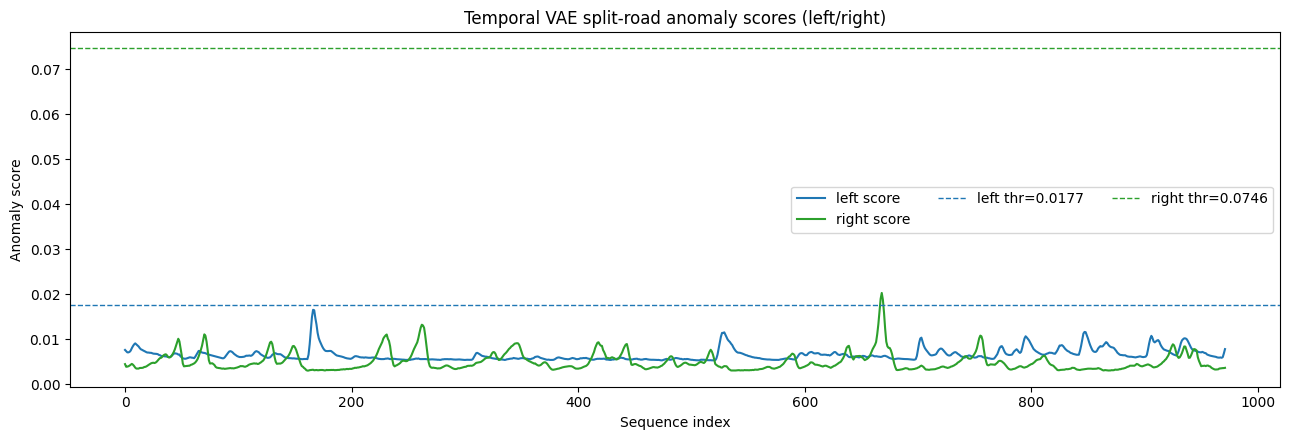

Saved split-road sequence results to vae_anomaly_scores_split_lr.csv


In [ ]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vae_anomaly_module import calibrate_threshold, detect_anomalies, anomaly_ratio

# --- 1) DETECTION CONFIG ---
PERCENTILE_LEFT = 98.5
PERCENTILE_RIGHT = 98.5
KL_WEIGHT = 0.05
SMOOTH_WINDOW = 3
SMOOTH_MIN_RATIO = 0.34

# --- 1b) LIVE WINDOW CONFIG ---
PLAYBACK_WITH_WINDOWS = True
PLAYBACK_WINDOW_SCALE = 0.70
PLAYBACK_MAX_FPS = 30
PLAYBACK_START_PAUSED = False
VIDEO_WINDOW_NAME = "VAE Timeline Video (Split)"
SCORE_WINDOW_NAME = "Temporal VAE Split Scores"

# Validate required objects from Cell 5
required = [
    "vae_model_left", "vae_model_right", "vae_device",
    "normal_loader_left", "normal_loader_right",
    "test_loader_left", "test_loader_right",
    "VAE_LEFT_ROI", "VAE_RIGHT_ROI",
    "vae_timeline_source",
 ]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Run Cell 5 first. Missing required split-VAE objects: " + ", ".join(missing)
    )

# --- 2) CALIBRATE LEFT/RIGHT THRESHOLDS ON NORMAL DATA ---
threshold_left, normal_scores_left = calibrate_threshold(
    model=vae_model_left,
    normal_loader=normal_loader_left,
    device=vae_device,
    percentile=PERCENTILE_LEFT,
    kl_weight=KL_WEIGHT,
)

threshold_right, normal_scores_right = calibrate_threshold(
    model=vae_model_right,
    normal_loader=normal_loader_right,
    device=vae_device,
    percentile=PERCENTILE_RIGHT,
    kl_weight=KL_WEIGHT,
)

# --- 3) SCORE TEST DATA LEFT/RIGHT ---
result_left = detect_anomalies(
    model=vae_model_left,
    test_loader=test_loader_left,
    device=vae_device,
    threshold=threshold_left,
    kl_weight=KL_WEIGHT,
    smooth_window=SMOOTH_WINDOW,
    smooth_min_ratio=SMOOTH_MIN_RATIO,
)

result_right = detect_anomalies(
    model=vae_model_right,
    test_loader=test_loader_right,
    device=vae_device,
    threshold=threshold_right,
    kl_weight=KL_WEIGHT,
    smooth_window=SMOOTH_WINDOW,
    smooth_min_ratio=SMOOTH_MIN_RATIO,
)

n = min(len(result_left.scores), len(result_right.scores))
if n == 0:
    raise RuntimeError("No sequences available after split scoring.")

if len(result_left.scores) != len(result_right.scores):
    print(f"Warning: left/right sequence count mismatch ({len(result_left.scores)} vs {len(result_right.scores)}). Using n={n}.")

scores_left = result_left.scores[:n]
scores_right = result_right.scores[:n]
flags_left_raw = result_left.raw_flags[:n]
flags_right_raw = result_right.raw_flags[:n]
flags_left_smooth = result_left.smoothed_flags[:n]
flags_right_smooth = result_right.smoothed_flags[:n]

flags_any_raw = np.logical_or(flags_left_raw, flags_right_raw)
flags_any_smooth = np.logical_or(flags_left_smooth, flags_right_smooth)

print(f"Left threshold:  {threshold_left:.6f}")
print(f"Right threshold: {threshold_right:.6f}")
print(f"Left normal mean/std:  {normal_scores_left.mean():.6f}/{normal_scores_left.std():.6f}")
print(f"Right normal mean/std: {normal_scores_right.mean():.6f}/{normal_scores_right.std():.6f}")
print(f"Left smoothed anomaly ratio:  {anomaly_ratio(flags_left_smooth):.4f}")
print(f"Right smoothed anomaly ratio: {anomaly_ratio(flags_right_smooth):.4f}")
print(f"Combined smoothed anomaly ratio: {anomaly_ratio(flags_any_smooth):.4f}")

# --- 4) TIMELINE MAPPING ---
def sec_to_hms(seconds: float) -> str:
    seconds = max(0.0, float(seconds))
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = seconds % 60
    return f"{h:02d}:{m:02d}:{s:06.3f}"

timeline_source = str(vae_timeline_source)
timeline_fps = None
timeline_total_frames = None
timeline_duration_s = None

if Path(timeline_source).is_file():
    cap = cv2.VideoCapture(timeline_source)
    if cap.isOpened():
        timeline_fps = float(cap.get(cv2.CAP_PROP_FPS))
        timeline_total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        timeline_duration_s = (timeline_total_frames / timeline_fps) if timeline_fps and timeline_fps > 0 else None
    cap.release()

if timeline_fps is None or timeline_fps <= 0:
    raise RuntimeError(f"Could not read FPS from timeline source: {timeline_source}")

seq_idx = np.arange(n, dtype=int)
frame_step = int(globals().get("VAE_FRAME_STEP", 1))
seq_stride = int(globals().get("VAE_SEQ_STRIDE", 1))
seq_len = int(globals().get("VAE_SEQ_LEN", 8))

frames_per_seq_shift = frame_step * seq_stride
start_frame = seq_idx * frames_per_seq_shift
end_frame = start_frame + (seq_len - 1) * frame_step
start_sec = start_frame / timeline_fps
end_sec = end_frame / timeline_fps
start_hms = [sec_to_hms(s) for s in start_sec]
end_hms = [sec_to_hms(s) for s in end_sec]

start_pct = np.full(n, np.nan)
end_pct = np.full(n, np.nan)
if timeline_duration_s is not None and timeline_duration_s > 0:
    start_pct = (start_sec / timeline_duration_s) * 100.0
    end_pct = (end_sec / timeline_duration_s) * 100.0

# --- 5) RESULT TABLE ---
result_df = pd.DataFrame({
    "sequence_idx": seq_idx,
    "score_left": scores_left,
    "score_right": scores_right,
    "score_max": np.maximum(scores_left, scores_right),
    "is_left_raw": flags_left_raw.astype(int),
    "is_right_raw": flags_right_raw.astype(int),
    "is_any_raw": flags_any_raw.astype(int),
    "is_left_smoothed": flags_left_smooth.astype(int),
    "is_right_smoothed": flags_right_smooth.astype(int),
    "is_any_smoothed": flags_any_smooth.astype(int),
    "start_frame": start_frame,
    "end_frame": end_frame,
    "start_sec": start_sec,
    "end_sec": end_sec,
    "start_hms": start_hms,
    "end_hms": end_hms,
    "start_pct": start_pct,
    "end_pct": end_pct,
})

print(f"Timeline source: {timeline_source}")
if timeline_duration_s is not None:
    print(f"Video FPS: {timeline_fps:.3f} | Duration: {sec_to_hms(timeline_duration_s)}")

anomaly_df = result_df[result_df["is_any_smoothed"] == 1].copy()
if anomaly_df.empty:
    print("No combined smoothed anomalies found.")
else:
    print(f"Combined smoothed anomaly windows found: {len(anomaly_df)}")
    preview_cols = [
        "sequence_idx", "score_left", "score_right", "score_max",
        "is_left_smoothed", "is_right_smoothed",
        "start_hms", "end_hms", "start_pct", "end_pct",
    ]
    display(anomaly_df.sort_values("score_max", ascending=False)[preview_cols].head(40).reset_index(drop=True))

top_k = min(25, len(result_df))
print(f"Top {top_k} combined anomaly sequences by max side score:")
display(result_df.sort_values("score_max", ascending=False).head(top_k).reset_index(drop=True))

# --- 6) QUICK PLOT (LEFT/RIGHT) ---
plt.figure(figsize=(13, 4.5))
plt.plot(scores_left, label="left score", linewidth=1.5, color="#1f77b4")
plt.plot(scores_right, label="right score", linewidth=1.5, color="#2ca02c")
plt.axhline(threshold_left, color="#1f77b4", linestyle="--", linewidth=1, label=f"left thr={threshold_left:.4f}")
plt.axhline(threshold_right, color="#2ca02c", linestyle="--", linewidth=1, label=f"right thr={threshold_right:.4f}")

idx_any = np.where(flags_any_smooth)[0]
if len(idx_any) > 0:
    ymax = np.maximum(scores_left[idx_any], scores_right[idx_any])
    plt.scatter(idx_any, ymax, s=16, c="orange", label="combined smoothed anomaly")

plt.title("Temporal VAE split-road anomaly scores (left/right)")
plt.xlabel("Sequence index")
plt.ylabel("Anomaly score")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

# CSV export
result_df.to_csv("vae_anomaly_scores_split_lr.csv", index=False)
print("Saved split-road sequence results to vae_anomaly_scores_split_lr.csv")

# --- 7) LIVE WINDOWS: VIDEO + SPLIT SCORE TIMELINE (SYNC + SEEK) ---
if PLAYBACK_WITH_WINDOWS:
    if not Path(timeline_source).is_file():
        print("Skip live windows: timeline source is not valid file.")
    else:
        score_h, score_w = 390, 1260
        left, right, top, bottom = 75, score_w - 25, 30, score_h - 85
        max_frame_for_x = max(int(timeline_total_frames or 1) - 1, 1)

        s_min = float(min(np.min(scores_left), np.min(scores_right))) if n > 0 else 0.0
        s_max = float(max(np.max(scores_left), np.max(scores_right))) if n > 0 else 1.0
        s_rng = max(s_max - s_min, 1e-9)

        x_arr = left + ((start_frame.astype(np.float32) / max_frame_for_x) * (right - left)).astype(np.int32)
        y_left = bottom - (((scores_left - s_min) / s_rng) * (bottom - top)).astype(np.int32)
        y_right = bottom - (((scores_right - s_min) / s_rng) * (bottom - top)).astype(np.int32)

        base = np.full((score_h, score_w, 3), 245, dtype=np.uint8)
        cv2.rectangle(base, (left, top), (right, bottom), (70, 70, 70), 1)
        cv2.putText(base, "Temporal VAE split timeline", (left, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.58, (40, 40, 40), 1)

        if n > 1:
            pts_l = np.stack([x_arr, y_left], axis=1).astype(np.int32)
            pts_r = np.stack([x_arr, y_right], axis=1).astype(np.int32)
            cv2.polylines(base, [pts_l], False, (190, 90, 40), 2)
            cv2.polylines(base, [pts_r], False, (40, 150, 40), 2)

            y_thr_l = int(bottom - ((threshold_left - s_min) / s_rng) * (bottom - top))
            y_thr_r = int(bottom - ((threshold_right - s_min) / s_rng) * (bottom - top))
            y_thr_l = max(top, min(bottom, y_thr_l))
            y_thr_r = max(top, min(bottom, y_thr_r))
            cv2.line(base, (left, y_thr_l), (right, y_thr_l), (190, 90, 40), 1)
            cv2.line(base, (left, y_thr_r), (right, y_thr_r), (40, 150, 40), 1)

            sm_idx = np.where(flags_any_smooth)[0]
            for i in sm_idx:
                y_any = int(min(y_left[i], y_right[i]))
                cv2.circle(base, (int(x_arr[i]), y_any), 2, (0, 140, 255), -1)

        cap2 = cv2.VideoCapture(str(timeline_source))
        if not cap2.isOpened():
            print(f"Skip live windows: cannot open {timeline_source}")
        else:
            cv2.namedWindow(VIDEO_WINDOW_NAME, cv2.WINDOW_NORMAL)
            cv2.namedWindow(SCORE_WINDOW_NAME, cv2.WINDOW_NORMAL)

            target_fps = min(max(float(timeline_fps), 1.0), float(PLAYBACK_MAX_FPS))
            wait_ms_play = max(1, int(1000.0 / target_fps))
            wait_ms_pause = 20

            state = {
                "seek_frame": None,
                "dragging": False,
                "paused": bool(PLAYBACK_START_PAUSED),
            }

            def clamp_frame(v: int) -> int:
                return int(max(0, min(max_frame_for_x, int(v))))

            def x_to_frame(x: int) -> int:
                x_clamped = int(max(left, min(right, x)))
                ratio = (x_clamped - left) / max(1, (right - left))
                return clamp_frame(int(round(ratio * max_frame_for_x)))

            def on_score_mouse(event, x, y, flags, param):
                if event == cv2.EVENT_LBUTTONDOWN:
                    state["dragging"] = True
                    state["paused"] = True
                    state["seek_frame"] = x_to_frame(x)
                elif event == cv2.EVENT_MOUSEMOVE and state["dragging"]:
                    state["seek_frame"] = x_to_frame(x)
                elif event == cv2.EVENT_LBUTTONUP:
                    state["dragging"] = False
                    state["seek_frame"] = x_to_frame(x)

            cv2.setMouseCallback(SCORE_WINDOW_NAME, on_score_mouse)

            f_idx = 0
            try:
                while True:
                    if state["seek_frame"] is not None:
                        f_idx = clamp_frame(state["seek_frame"] )
                        state["seek_frame"] = None

                    if f_idx > max_frame_for_x:
                        break

                    cap2.set(cv2.CAP_PROP_POS_FRAMES, f_idx)
                    ok, frame = cap2.read()
                    if not ok:
                        break

                    if PLAYBACK_WINDOW_SCALE != 1.0:
                        h0, w0 = frame.shape[:2]
                        nw = max(1, int(w0 * PLAYBACK_WINDOW_SCALE))
                        nh = max(1, int(h0 * PLAYBACK_WINDOW_SCALE))
                        frame = cv2.resize(frame, (nw, nh), interpolation=cv2.INTER_AREA)

                    # Draw divider and left/right labels
                    if max_frame_for_x > 0 and timeline_total_frames and timeline_total_frames > 0:
                        fx = frame.shape[1] / float(timeline_total_frames)
                        divider_on_frame = int(round(globals().get("road_divider_x", int(frame_w / 1.88)) * PLAYBACK_WINDOW_SCALE))
                        divider_on_frame = max(0, min(frame.shape[1] - 1, divider_on_frame))
                        cv2.line(frame, (divider_on_frame, 0), (divider_on_frame, frame.shape[0] - 1), (0, 255, 255), 1)
                        cv2.putText(frame, "L", (max(5, divider_on_frame - 40), 20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 220, 0), 2)
                        cv2.putText(frame, "R", (min(frame.shape[1] - 25, divider_on_frame + 10), 20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 220, 255), 2)

                    chart = base.copy()
                    x_cur = int(left + (min(f_idx, max_frame_for_x) / max_frame_for_x) * (right - left))
                    cv2.line(chart, (x_cur, top), (x_cur, bottom), (0, 0, 255), 2)

                    seq_i = int(np.searchsorted(start_frame, f_idx, side="right") - 1)
                    txt = "seq:N/A"
                    if 0 <= seq_i < n:
                        txt = (
                            f"seq:{seq_i} | L:{scores_left[seq_i]:.4f} ({int(flags_left_smooth[seq_i])}) "
                            f"| R:{scores_right[seq_i]:.4f} ({int(flags_right_smooth[seq_i])}) "
                            f"| any:{int(flags_any_smooth[seq_i])}"
                        )

                    t_sec = f_idx / float(timeline_fps)
                    status = "PAUSED" if state["paused"] else "PLAY"
                    cv2.putText(chart, txt, (left + 8, bottom + 22), cv2.FONT_HERSHEY_SIMPLEX, 0.48, (30, 30, 30), 1)
                    cv2.putText(chart, f"time: {sec_to_hms(t_sec)} | {status}", (left + 8, bottom + 42), cv2.FONT_HERSHEY_SIMPLEX, 0.48, (30, 30, 30), 1)
                    cv2.putText(
                        chart,
                        "Mouse seek | SPACE pause/play | A/D step | Q/ESC quit",
                        (left + 8, bottom + 62),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.46,
                        (60, 60, 60),
                        1,
                    )

                    cv2.putText(frame, f"t={sec_to_hms(t_sec)}", (12, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

                    cv2.imshow(VIDEO_WINDOW_NAME, frame)
                    cv2.imshow(SCORE_WINDOW_NAME, chart)

                    key = cv2.waitKey(wait_ms_play if not state["paused"] else wait_ms_pause) & 0xFF
                    if key in (27, ord("q")):
                        break
                    if key == ord(" "):
                        state["paused"] = not state["paused"]
                    elif key in (ord("a"), ord("A")):
                        state["paused"] = True
                        f_idx = clamp_frame(f_idx - 1)
                    elif key in (ord("d"), ord("D")):
                        state["paused"] = True
                        f_idx = clamp_frame(f_idx + 1)
                    elif not state["paused"]:
                        f_idx = clamp_frame(f_idx + 1)
            finally:
                cap2.release()
                try:
                    cv2.destroyWindow(VIDEO_WINDOW_NAME)
                    cv2.destroyWindow(SCORE_WINDOW_NAME)
                except cv2.error:
                    pass
                cv2.waitKey(1)

In [ ]:
from pathlib import Path
from collections import deque
import cv2
import numpy as np
from ultralytics import YOLO

# --- ByteTrack + Split-VAE + Wrong-Way Visual Overlay ---
# Run this after Cell 5 and Cell 6.

TRACK_MODEL_PATH = str(globals().get("model_path", "yolo11m.pt"))
TRACKER_CFG_PATH = str(globals().get("tracker_cfg", "bytetrack_tuned.yaml"))
TRACK_SOURCE = str(globals().get("vae_timeline_source", "11x_monitoring_output.mp4"))
TRACK_OUTPUT_VIDEO = "vae_bytetrack_anomaly_overlay.mp4"
TRACK_CLASSES = [int(c) for c in globals().get("target_classes", [2, 3, 5, 7])]

# Too-low conf can pull in foliage noise; keep moderate for stability.
TRACK_CONF = 0.20
TRACK_IOU = 0.50
SHOW_WINDOWS = False
WINDOW_NAME = "ByteTrack + Split VAE + Wrong-Way Overlay"

# Visual style (BGR colors)
ANOMALY_COLOR = (0, 0, 255)
NORMAL_COLOR = (0, 200, 0)
WRONG_WAY_ONLY_COLOR = (0, 80, 255)
ANOMALY_TEXT_COLOR = (0, 0, 255)
ANOMALY_BORDER_THICKNESS = 4

# Stable display-ID remapping to reduce visible ID flicker after short drops/switches.
ENABLE_STABLE_ID_REMAP = True
STABLE_ID_MAX_AGE = 45          # frames to keep a stable ID candidate alive
STABLE_ID_MAX_DIST = 120.0      # max pixel distance for ID re-association
STABLE_ID_SAME_CLASS_ONLY = True
SHOW_RAW_ID = False

# Wrong-way settings (camera convention from Cell 1):
# left side wrong-way => moving down (dy > 0), right side wrong-way => moving up (dy < 0)
ENABLE_WRONG_WAY_RULE = True
WRONG_WAY_HISTORY = 8
WRONG_WAY_MIN_SAMPLES = 6
WRONG_WAY_DY_THRESHOLD = 1.6
WRONG_WAY_LATCH_FRAMES = 30

required = [
    "start_frame",
    "scores_left", "scores_right",
    "flags_left_smooth", "flags_right_smooth", "flags_any_smooth",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Run Cell 5 and Cell 6 first. Missing required outputs: " + ", ".join(missing)
    )

model_path = Path(TRACK_MODEL_PATH)
tracker_cfg_path = Path(TRACKER_CFG_PATH)
source_path = Path(TRACK_SOURCE)
if not model_path.exists():
    raise FileNotFoundError(f"YOLO model not found: {model_path}")
if not tracker_cfg_path.exists():
    raise FileNotFoundError(f"Tracker config not found: {tracker_cfg_path}")
if not source_path.exists():
    raise FileNotFoundError(f"Track source not found: {source_path}")

if "sec_to_hms" in globals():
    to_hms = sec_to_hms
else:
    def to_hms(seconds: float) -> str:
        seconds = max(0.0, float(seconds))
        h = int(seconds // 3600)
        m = int((seconds % 3600) // 60)
        s = seconds % 60
        return f"{h:02d}:{m:02d}:{s:06.3f}"

start_frame_arr = np.asarray(start_frame).astype(int)
scores_left_arr = np.asarray(scores_left).astype(np.float32)
scores_right_arr = np.asarray(scores_right).astype(np.float32)
flags_left_arr = np.asarray(flags_left_smooth).astype(bool)
flags_right_arr = np.asarray(flags_right_smooth).astype(bool)
flags_any_arr = np.asarray(flags_any_smooth).astype(bool)

n_seq = min(
    len(start_frame_arr),
    len(scores_left_arr), len(scores_right_arr),
    len(flags_left_arr), len(flags_right_arr), len(flags_any_arr),
)
if n_seq == 0:
    raise RuntimeError("No sequence scores/flags found. Run Cell 6 first.")

start_frame_arr = start_frame_arr[:n_seq]
scores_left_arr = scores_left_arr[:n_seq]
scores_right_arr = scores_right_arr[:n_seq]
flags_left_arr = flags_left_arr[:n_seq]
flags_right_arr = flags_right_arr[:n_seq]
flags_any_arr = flags_any_arr[:n_seq]

cap_meta = cv2.VideoCapture(str(source_path))
if not cap_meta.isOpened():
    raise RuntimeError(f"Cannot open source video: {source_path}")
fps = float(cap_meta.get(cv2.CAP_PROP_FPS))
fps = fps if fps > 0 else 30.0
frame_w = int(cap_meta.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(cap_meta.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap_meta.get(cv2.CAP_PROP_FRAME_COUNT))
cap_meta.release()

divider_default = int(frame_w / 1.88)
divider_x = int(globals().get("road_divider_x", globals().get("divider_x", divider_default)))
divider_x = max(0, min(frame_w - 1, divider_x))

output_path = Path(TRACK_OUTPUT_VIDEO)
writer = cv2.VideoWriter(
    str(output_path),
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (frame_w, frame_h),
)
if not writer.isOpened():
    raise RuntimeError(f"Cannot open output video writer: {output_path}")

print("Starting ByteTrack + VAE + wrong-way overlay...")
print(f"Model: {model_path}")
print(f"Tracker cfg: {tracker_cfg_path}")
print(f"Source: {source_path}")
print(f"Output: {output_path}")
print(f"Frame size: {frame_w}x{frame_h} | FPS: {fps:.3f} | Total frames: {total_frames}")
print(f"Divider x: {divider_x}")
print(f"Tracker params: conf={TRACK_CONF}, iou={TRACK_IOU}")
print(
    f"Wrong-way: enabled={ENABLE_WRONG_WAY_RULE}, dy_thr={WRONG_WAY_DY_THRESHOLD}, "
    f"history={WRONG_WAY_HISTORY}, min_samples={WRONG_WAY_MIN_SAMPLES}, latch={WRONG_WAY_LATCH_FRAMES}"
)

tracker_model = YOLO(str(model_path))
stream = tracker_model.track(
    source=str(source_path),
    stream=True,
    persist=True,
    tracker=str(tracker_cfg_path),
    classes=TRACK_CLASSES,
    conf=TRACK_CONF,
    iou=TRACK_IOU,
    verbose=False,
)

stable_tracks = {}
raw_to_stable = {}
next_stable_id = 1

track_motion = {}
wrong_way_latch_until = {}
wrong_way_seen = set()

try:
    for frame_idx, res in enumerate(stream):
        frame = res.orig_img.copy()
        if frame is None:
            continue

        # Drop stale stable-id candidates.
        for sid in list(stable_tracks.keys()):
            if frame_idx - stable_tracks[sid]["last_frame"] > STABLE_ID_MAX_AGE:
                del stable_tracks[sid]

        # Drop raw->stable mappings that no longer point to active stable IDs.
        for rid in list(raw_to_stable.keys()):
            if raw_to_stable[rid] not in stable_tracks:
                del raw_to_stable[rid]

        # Drop stale motion tracks and stale wrong-way latches.
        stale_limit = max(STABLE_ID_MAX_AGE, WRONG_WAY_HISTORY + WRONG_WAY_LATCH_FRAMES)
        for tid in list(track_motion.keys()):
            if frame_idx - track_motion[tid]["last_frame"] > stale_limit:
                del track_motion[tid]
        for tid in list(wrong_way_latch_until.keys()):
            if frame_idx > wrong_way_latch_until[tid] + stale_limit:
                del wrong_way_latch_until[tid]

        seq_i = int(np.searchsorted(start_frame_arr, frame_idx, side="right") - 1)
        seq_valid = 0 <= seq_i < n_seq

        left_anom = bool(flags_left_arr[seq_i]) if seq_valid else False
        right_anom = bool(flags_right_arr[seq_i]) if seq_valid else False
        any_anom = bool(flags_any_arr[seq_i]) if seq_valid else False
        left_score = float(scores_left_arr[seq_i]) if seq_valid else 0.0
        right_score = float(scores_right_arr[seq_i]) if seq_valid else 0.0

        # Draw divider.
        cv2.line(frame, (divider_x, 0), (divider_x, frame_h - 1), (0, 255, 255), 1)
        cv2.putText(frame, "L", (max(5, divider_x - 30), 22), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 220, 0), 2)
        cv2.putText(frame, "R", (min(frame_w - 20, divider_x + 10), 22), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 220, 255), 2)

        boxes = getattr(res, "boxes", None)
        if boxes is not None and len(boxes) > 0:
            xyxy = boxes.xyxy.detach().cpu().numpy() if boxes.xyxy is not None else np.zeros((0, 4), dtype=np.float32)
            ids = boxes.id.int().detach().cpu().numpy() if boxes.id is not None else np.full((len(xyxy),), -1, dtype=np.int32)
            confs = boxes.conf.detach().cpu().numpy() if boxes.conf is not None else np.zeros((len(xyxy),), dtype=np.float32)
            clss = boxes.cls.int().detach().cpu().numpy() if boxes.cls is not None else np.full((len(xyxy),), -1, dtype=np.int32)

            for (x1, y1, x2, y2), tid, conf, cls_id in zip(xyxy, ids, confs, clss):
                x1i, y1i, x2i, y2i = int(x1), int(y1), int(x2), int(y2)
                cx = float(0.5 * (x1 + x2))
                cy = float(0.5 * (y1 + y2))
                raw_tid = int(tid)
                det_cls = int(cls_id)

                if ENABLE_STABLE_ID_REMAP and raw_tid >= 0:
                    stable_id = raw_to_stable.get(raw_tid)
                    if stable_id is None or stable_id not in stable_tracks:
                        best_sid = None
                        best_dist = 1e12
                        for cand_sid, st in stable_tracks.items():
                            if frame_idx - st["last_frame"] > STABLE_ID_MAX_AGE:
                                continue
                            if STABLE_ID_SAME_CLASS_ONLY and st["cls"] != det_cls:
                                continue
                            d = float(np.hypot(cx - st["cx"], cy - st["cy"]))
                            if d <= STABLE_ID_MAX_DIST and d < best_dist:
                                best_dist = d
                                best_sid = cand_sid

                        if best_sid is None:
                            stable_id = next_stable_id
                            next_stable_id += 1
                        else:
                            stable_id = best_sid

                        raw_to_stable[raw_tid] = stable_id

                    stable_tracks[stable_id] = {
                        "cx": cx,
                        "cy": cy,
                        "last_frame": frame_idx,
                        "cls": det_cls,
                    }
                else:
                    stable_id = raw_tid

                track_id_for_motion = stable_id if stable_id >= 0 else raw_tid
                is_left = cx <= divider_x
                side_anom = left_anom if is_left else right_anom
                side_score = left_score if is_left else right_score
                side_tag = "L" if is_left else "R"

                wrong_way = False
                if ENABLE_WRONG_WAY_RULE and track_id_for_motion >= 0:
                    if track_id_for_motion not in track_motion:
                        track_motion[track_id_for_motion] = {
                            "last_y": cy,
                            "dy_hist": deque(maxlen=WRONG_WAY_HISTORY),
                            "last_frame": frame_idx,
                        }
                    else:
                        tm = track_motion[track_id_for_motion]
                        dy = cy - tm["last_y"]
                        tm["dy_hist"].append(float(dy))
                        tm["last_y"] = cy
                        tm["last_frame"] = frame_idx

                        if len(tm["dy_hist"]) >= WRONG_WAY_MIN_SAMPLES:
                            mean_dy = float(np.mean(tm["dy_hist"]))
                            wrong_left = is_left and (mean_dy > WRONG_WAY_DY_THRESHOLD)
                            wrong_right = (not is_left) and (mean_dy < -WRONG_WAY_DY_THRESHOLD)
                            if wrong_left or wrong_right:
                                wrong_way_latch_until[track_id_for_motion] = frame_idx + WRONG_WAY_LATCH_FRAMES
                                wrong_way_seen.add(track_id_for_motion)

                    latch_end = wrong_way_latch_until.get(track_id_for_motion, -1)
                    wrong_way = frame_idx <= latch_end

                if side_anom and wrong_way:
                    state = "ANOM+WRONG-WAY"
                    color = ANOMALY_COLOR
                elif wrong_way:
                    state = "WRONG-WAY"
                    color = WRONG_WAY_ONLY_COLOR
                elif side_anom:
                    state = "ANOM(VAE)"
                    color = ANOMALY_COLOR
                else:
                    state = "OK"
                    color = NORMAL_COLOR

                cv2.rectangle(frame, (x1i, y1i), (x2i, y2i), color, 2)

                id_text = f"S{stable_id}" if stable_id >= 0 else "S?"
                if SHOW_RAW_ID and raw_tid >= 0:
                    id_text = f"S{stable_id}/R{raw_tid}"

                label = f"{id_text} C{det_cls} {side_tag}:{state} s={side_score:.3f} c={float(conf):.2f}"
                cv2.putText(
                    frame,
                    label,
                    (x1i, max(18, y1i - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    color,
                    2,
                )

        # Top status panel.
        overlay = frame.copy()
        cv2.rectangle(overlay, (0, 0), (frame_w, 86), (20, 20, 20), -1)
        alpha = 0.50
        cv2.addWeighted(overlay, alpha, frame, 1 - alpha, 0, frame)

        t_sec = frame_idx / fps
        seq_txt = f"seq:{seq_i}" if seq_valid else "seq:N/A"
        cv2.putText(
            frame,
            f"t={to_hms(t_sec)} | {seq_txt} | vae_any={int(any_anom)}",
            (10, 24),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.62,
            (255, 255, 255),
            2,
        )
        cv2.putText(
            frame,
            f"L score={left_score:.4f} flag={int(left_anom)} | R score={right_score:.4f} flag={int(right_anom)}",
            (10, 50),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.56,
            (255, 255, 255),
            2,
        )
        cv2.putText(
            frame,
            f"Wrong-way tracked IDs: {len(wrong_way_seen)}",
            (10, 74),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.56,
            (255, 210, 120),
            2,
        )

        if any_anom:
            cv2.rectangle(frame, (0, 0), (frame_w - 1, frame_h - 1), ANOMALY_COLOR, ANOMALY_BORDER_THICKNESS)
            cv2.putText(
                frame,
                "ANOMALY ACTIVE",
                (frame_w - 260, 28),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.70,
                ANOMALY_TEXT_COLOR,
                2,
            )

        writer.write(frame)

        if SHOW_WINDOWS:
            cv2.imshow(WINDOW_NAME, frame)
            key = cv2.waitKey(1) & 0xFF
            if key in (27, ord("q")):
                print("Stopped by user.")
                break

        if frame_idx % 100 == 0:
            print(f"Processed frame {frame_idx}/{max(total_frames - 1, 0)}")
finally:
    writer.release()
    if SHOW_WINDOWS:
        try:
            cv2.destroyWindow(WINDOW_NAME)
        except cv2.error:
            pass
        cv2.waitKey(1)

print(f"Saved anomaly overlay video: {output_path}")

Starting ByteTrack + VAE + wrong-way overlay...
Model: yolo11m.pt
Tracker cfg: bytetrack_tuned.yaml
Source: CCTV_Sleman.mp4
Output: vae_bytetrack_anomaly_overlay.mp4
Frame size: 1920x1080 | FPS: 30.000 | Total frames: 3899
Divider x: 1021
Tracker params: conf=0.1, iou=0.5
Wrong-way: enabled=True, dy_thr=1.6, history=8, min_samples=6, latch=30
Processed frame 0/3898
Processed frame 100/3898
Processed frame 200/3898
Processed frame 300/3898
Processed frame 400/3898
Processed frame 500/3898
Processed frame 600/3898
Processed frame 700/3898
Processed frame 800/3898
Processed frame 900/3898
Processed frame 1000/3898
Processed frame 1100/3898
Processed frame 1200/3898
Processed frame 1300/3898
Processed frame 1400/3898
Processed frame 1500/3898
Processed frame 1600/3898
Processed frame 1700/3898
Processed frame 1800/3898
Processed frame 1900/3898
Processed frame 2000/3898
Processed frame 2100/3898
Processed frame 2200/3898
Processed frame 2300/3898
Processed frame 2400/3898
Processed frame 2